# Portfolio Risk & Market Analysis

This project analyses historical market data using Python and SQL to evaluate portfolio returns, volatility, diversification and downside risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import sqlite3 

## 1. Market Data and Asset Selection

This project uses six ETFs with different market exposures:

- **SPY** — tracks the S&P 500
- **QQQ** — tracks the Nasdaq-100
- **XLF** — US financial companies
- **XLK** — US technology companies
- **GLD** — gold
- **IEF** — US government bonds

The ETFs were chosen to include different types of investments. Some have similar exposures, while others behave differently. This will help analyse how combining different assets can affect the risk of a portfolio.

In [2]:
tickers = ["SPY", "QQQ", "XLF", "XLK", "GLD", "IEF"]

prices = yf.download(
    tickers,
    start="2021-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

In [3]:
prices.shape

(1419, 6)

### Data Quality Check

Before calculating returns, the data is checked for missing values and incorrect data types. This helps ensure that the following calculations are based on complete and consistent price data.

In [4]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1419 entries, 2021-01-04 to 2026-08-27
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GLD     1419 non-null   float64
 1   IEF     1419 non-null   float64
 2   QQQ     1419 non-null   float64
 3   SPY     1419 non-null   float64
 4   XLF     1419 non-null   float64
 5   XLK     1419 non-null   float64
dtypes: float64(6)
memory usage: 77.6 KB


In [5]:
prices.isna().sum()

Ticker
GLD    0
IEF    0
QQQ    0
SPY    0
XLF    0
XLK    0
dtype: int64

### Preparing Data for SQL

The downloaded price data is stored in wide format, with one column for each ETF.  
For SQL, the data is converted into long format with three columns: date, ticker, and close price. This makes the table easier to query and extend with additional assets.

In [6]:
prices_long = (
    prices
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="ticker",
        value_name="close"
    )
)
prices_long = prices_long.rename(
    columns={"Date": "date"}
)


In [7]:
prices_long.head(5)

,date,ticker,close
0,2021-01-04,GLD,182.330002
1,2021-01-05,GLD,182.869995
2,2021-01-06,GLD,179.899994
3,2021-01-07,GLD,179.479996
4,2021-01-08,GLD,173.339996


In [8]:
prices_long.shape

(8514, 3)

## 2. SQL Data Storage

The historical price data is stored in a SQLite database. This allows the data to be queried and filtered using SQL before carrying out the financial analysis in Python.

In [9]:
connection = sqlite3.connect("data/market_data.db")

In [10]:
prices_long.to_sql(
    "prices",
    connection,
    if_exists="replace",
    index=False
)

8514

In [11]:
#sql check
query = """
SELECT *
FROM prices
LIMIT 10;
"""

pd.read_sql(query, connection)

,date,ticker,close
0,2021-01-04 00:00:00,GLD,182.330002
1,2021-01-05 00:00:00,GLD,182.869995
2,2021-01-06 00:00:00,GLD,179.899994
3,2021-01-07 00:00:00,GLD,179.479996
4,2021-01-08 00:00:00,GLD,173.339996
5,2021-01-11 00:00:00,GLD,173.000000
6,2021-01-12 00:00:00,GLD,174.119995
7,2021-01-13 00:00:00,GLD,173.369995
8,2021-01-14 00:00:00,GLD,173.279999
9,2021-01-15 00:00:00,GLD,171.130005


### SQL Validation and Data Retrieval

The SQLite database is used to validate the stored market data and retrieve subsets of observations for further analysis in Python.

In [12]:
query = """
SELECT MIN(date) AS first_date, MAX(date) AS last_date, COUNT(*) AS total_rows
FROM prices;
"""

pd.read_sql(query, connection)

,first_date,last_date,total_rows
0,2021-01-04 00:00:00,2026-08-27 00:00:00,8514


In [13]:
query = """
SELECT ticker, COUNT(*) AS observations
FROM prices
GROUP BY ticker
ORDER BY ticker;
"""

pd.read_sql(query, connection)

,ticker,observations
0,GLD,1419
1,IEF,1419
2,QQQ,1419
3,SPY,1419
4,XLF,1419
5,XLK,1419


In [14]:
query = """
SELECT date, ticker,close
FROM prices
WHERE ticker = 'SPY'
ORDER BY date;
"""

spy_prices = pd.read_sql(query, connection)

spy_prices.head()

,date,ticker,close
0,2021-01-04 00:00:00,SPY,342.436920
1,2021-01-05 00:00:00,SPY,344.795532
2,2021-01-06 00:00:00,SPY,346.856812
3,2021-01-07 00:00:00,SPY,352.010162
4,2021-01-08 00:00:00,SPY,354.015869


## 3. Return Analysis

Daily returns are calculated from adjusted closing prices to measure the percentage change in each ETF's value between consecutive trading days. Returns make it possible to compare the performance and risk of assets with different price levels.

In [15]:
returns = prices.pct_change().dropna()

In [16]:
returns.head()

Ticker,GLD,IEF,QQQ,SPY,XLF,XLK
Date,,,,,,
2021-01-05,0.002962,-0.002334,0.008244,0.006888,0.004470,0.006490
2021-01-06,-0.016241,-0.005848,-0.013852,0.005978,0.044163,-0.017245
2021-01-07,-0.002335,-0.003529,0.024193,0.014857,0.014426,0.026954
2021-01-08,-0.034210,-0.002868,0.012858,0.005698,-0.000646,0.006465
2021-01-11,-0.001961,-0.001945,-0.014450,-0.006741,0.003234,-0.008259


In [17]:
returns.describe()

Ticker,GLD,IEF,QQQ,SPY,XLF,XLK
count,1418.000000,1418.000000,1418.000000,1418.000000,1418.000000,1418.000000
mean,0.000660,-0.000059,0.000719,0.000629,0.000622,0.000917
std,0.011480,0.004690,0.014183,0.010540,0.011645,0.015900
min,-0.102742,-0.017770,-0.062109,-0.058543,-0.073181,-0.068248
25%,-0.005056,-0.002988,-0.006575,-0.004423,-0.005674,-0.008221
50%,0.000638,-0.000105,0.001123,0.000746,0.000864,0.001498
75%,0.006734,0.002769,0.008523,0.006306,0.007348,0.010115
max,0.063587,0.022525,0.120031,0.105019,0.075364,0.134257


In [18]:
returns_long = (
    returns
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="ticker",
        value_name="daily_return"
    )
    .rename(columns={"Date": "date"})
) 
returns_long.to_sql(
    "returns",
    connection,
    if_exists="replace",
    index=False
)

8508

## 4. Return and Volatility

Average return measures the historical performance of each ETF, while volatility measures how much its daily returns vary over time.

Daily statistics are annualised to make the results easier to compare on a yearly basis.

In [19]:
mean_daily_return = returns.mean()

mean_daily_return

Ticker
GLD    0.000660
IEF   -0.000059
QQQ    0.000719
SPY    0.000629
XLF    0.000622
XLK    0.000917
dtype: float64

In [20]:
annual_return = mean_daily_return * 252

annual_return

Ticker
GLD    0.166263
IEF   -0.014928
QQQ    0.181277
SPY    0.158465
XLF    0.156839
XLK    0.231072
dtype: float64

In [21]:
daily_variance = returns.var()

daily_variance

Ticker
GLD    0.000132
IEF    0.000022
QQQ    0.000201
SPY    0.000111
XLF    0.000136
XLK    0.000253
dtype: float64

In [22]:
daily_volatility = returns.std()

daily_volatility

Ticker
GLD    0.011480
IEF    0.004690
QQQ    0.014183
SPY    0.010540
XLF    0.011645
XLK    0.015900
dtype: float64

In [23]:
annual_volatility = daily_volatility * np.sqrt(252)

annual_volatility

Ticker
GLD    0.182239
IEF    0.074452
QQQ    0.225153
SPY    0.167325
XLF    0.184856
XLK    0.252405
dtype: float64

In [24]:
summary_stats = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility,
    "Daily Variance": daily_variance
})

summary_display = summary_stats.copy()

summary_display["Annual Return"] = (
    summary_display["Annual Return"] * 100
)

summary_display["Annual Volatility"] = (
    summary_display["Annual Volatility"] * 100
)

summary_display

,Annual Return,Annual Volatility,Daily Variance
Ticker,,,
GLD,16.626291,18.223889,0.000132
IEF,-1.492847,7.445177,0.000022
QQQ,18.127727,22.515289,0.000201
SPY,15.846528,16.732517,0.000111
XLF,15.683926,18.485570,0.000136
XLK,23.107193,25.240542,0.000253


### Observations

- XLK had the highest annualised return (23.02%) and the highest volatility (25.23%) over the sample period.
- QQQ also had a higher return than SPY, but with higher volatility.
- IEF had the lowest volatility (7.45%) but a negative annualised return.
- These results show that historical return should be considered together with the level of risk taken.

## 5. Correlation and Diversification

Correlation measures how closely the returns of different assets move together. Assets with lower correlations can provide diversification benefits when combined in a portfolio.
The correlation and covariance matrices are used to examine the relationships between the six ETFs.

In [25]:
cov_matrix = returns.cov()
annual_cov_matrix = cov_matrix * 252
annual_cov_matrix

Ticker,GLD,IEF,QQQ,SPY,XLF,XLK
Ticker,,,,,,
GLD,0.033211,0.004093,0.006308,0.004753,0.001181,0.007216
IEF,0.004093,0.005543,0.001654,0.001104,-0.000559,0.001355
QQQ,0.006308,0.001654,0.050694,0.035541,0.024541,0.054966
SPY,0.004753,0.001104,0.035541,0.027998,0.023997,0.038498
XLF,0.001181,-0.000559,0.024541,0.023997,0.034172,0.025622
XLK,0.007216,0.001355,0.054966,0.038498,0.025622,0.063708


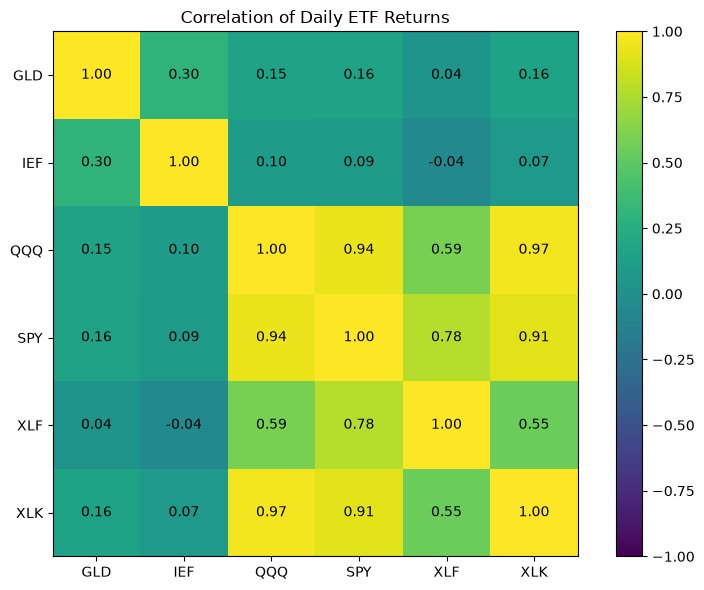

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = returns.corr()


image = ax.imshow(corr_matrix, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation of Daily ETF Returns")

plt.colorbar(image)
plt.tight_layout()
plt.savefig(
    "figures/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observations

- QQQ and XLK have the highest correlation (0.97), showing that their returns move very closely together.
- SPY is also highly correlated with QQQ (0.94) and XLK (0.91), suggesting significant overlap between these equity exposures.
- GLD and IEF have much lower correlations with the equity ETFs.
- This suggests that adding different asset classes may provide more diversification than simply adding more highly correlated equity ETFs.

## 6. Portfolio Construction

An equally weighted portfolio is used as a baseline, with the same proportion invested in each of the six ETFs.
The portfolio's return and volatility are calculated using the historical returns and covariance between the assets.

In [27]:
weights = np.array([1/6] * 6)

weights

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [28]:
annual_return.index
portfolio_return = np.dot(weights, annual_return)

portfolio_return

np.float64(0.14649802902041958)

In [29]:
portfolio_variance = (
    weights.T @ annual_cov_matrix.values @ weights
)

portfolio_variance

np.float64(0.018774039688025115)

In [30]:
portfolio_volatility = np.sqrt(portfolio_variance)

portfolio_volatility

np.float64(0.13701839178747177)

In [31]:
portfolio_summary = pd.Series({
    "Annual Return": portfolio_return,
    "Annual Volatility": portfolio_volatility
})

portfolio_summary*100

Annual Return        14.649803
Annual Volatility    13.701839
dtype: float64

In [32]:
weighted_avg_volatility = np.dot(weights, annual_volatility)

print(f"Weighted average individual volatility: {weighted_avg_volatility:.2%}")
print(f"Actual portfolio volatility: {portfolio_volatility:.2%}")

Weighted average individual volatility: 18.11%
Actual portfolio volatility: 13.70%


## 7. Portfolio Performance

The daily return of the equally weighted portfolio is calculated from the returns of its individual assets.
Cumulative returns are then used to show how the value of an initial investment would have changed over the sample period.

In [33]:
portfolio_daily_returns = returns @ weights

portfolio_daily_returns.head()

Date
2021-01-05    0.004453
2021-01-06   -0.000508
2021-01-07    0.012428
2021-01-08   -0.002117
2021-01-11   -0.005021
dtype: float64

In [34]:
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()
portfolio_cumulative.head()

Date
2021-01-05    1.004453
2021-01-06    1.003943
2021-01-07    1.016420
2021-01-08    1.014268
2021-01-11    1.009176
dtype: float64

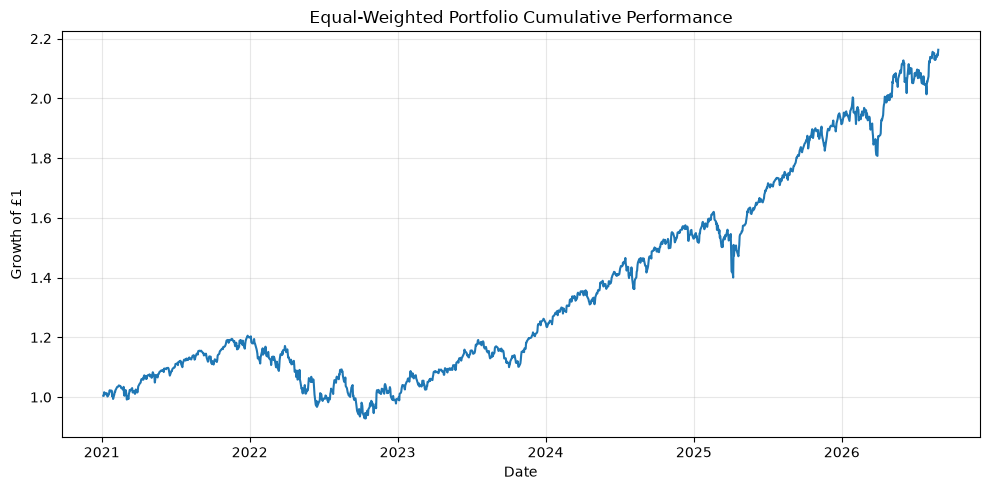

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    portfolio_cumulative.index,
    portfolio_cumulative
)

plt.title("Equal-Weighted Portfolio Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "figures/cumulative_performance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [36]:
cumulative_return = portfolio_cumulative.iloc[-1] - 1

print(f"Cumulative return: {cumulative_return:.2%}")

Cumulative return: 116.29%


In [37]:
years = (
    portfolio_cumulative.index[-1]
    - portfolio_cumulative.index[0]
).days / 365.25

cagr = portfolio_cumulative.iloc[-1] ** (1 / years) - 1

print(f"CAGR: {cagr:.2%}")

CAGR: 14.66%


### Portfolio Performance

Over the sample period, the equal-weighted portfolio produced a cumulative return of **X%**, with a CAGR of **Y%**.
The calculation assumes constant portfolio weights and therefore regular rebalancing back to the target allocation.

## 8. Drawdown Analysis

Drawdown measures the decline in portfolio value from a previous peak. Maximum drawdown shows the largest peak-to-trough loss over the sample period.

In [38]:
running_peak = portfolio_cumulative.cummax()
drawdown = portfolio_cumulative / running_peak - 1

In [39]:
max_drawdown = drawdown.min()

print(f"Maximum drawdown: {max_drawdown:.2%}")

Maximum drawdown: -23.00%


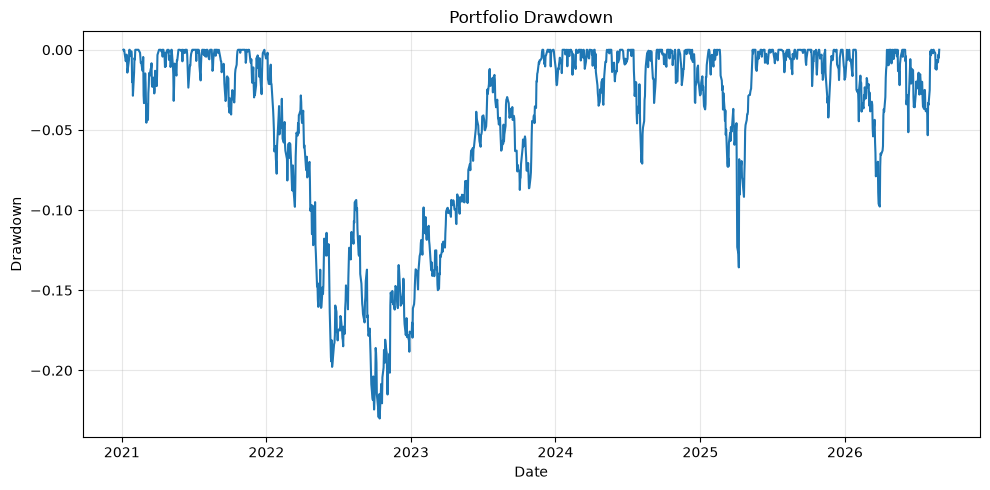

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(drawdown.index, drawdown)

plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "figures/drawdown.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [41]:
max_drawdown_date = drawdown.idxmin()

print(f"Date: {max_drawdown_date}")
print(f"Portfolio value: {portfolio_cumulative.loc[max_drawdown_date]:.3}")

peak_value = running_peak.loc[max_drawdown_date]
peak_date = portfolio_cumulative.loc[:max_drawdown_date].idxmax()

print(f"Peak date: {peak_date}")
print(f"Peak value: {peak_value:.3f}")

Date: 2022-10-14 00:00:00
Portfolio value: 0.928
Peak date: 2021-12-27 00:00:00
Peak value: 1.206


### Observation

The portfolio's maximum drawdown was **23.00%**, falling from a peak of 1.206 on 27 December 2021 to 0.928 on 14 October 2022.

## 9. Value at Risk (VaR)

Historical Value at Risk estimates a loss threshold using the observed distribution of portfolio returns.
A 95% one-day VaR represents the loss threshold exceeded on approximately 5% of historical trading days.

In [42]:
var_95 = portfolio_daily_returns.quantile(0.05)
var_99 = portfolio_daily_returns.quantile(0.01)

print(f"95% Historical VaR: {var_95:.2%}")
print(f"99% Historical VaR: {var_99:.2%}")

95% Historical VaR: -1.34%
99% Historical VaR: -2.33%


In [43]:
portfolio_value = 100_000
var_95_amount = portfolio_value * abs(var_95)
var_99_amount = portfolio_value * abs(var_99)

print(f"95% VaR on £100,000: £{var_95_amount:,.2f}")
print(f"99% VaR on £100,000: £{var_99_amount:,.2f}")

95% VaR on £100,000: £1,342.00
99% VaR on £100,000: £2,330.62


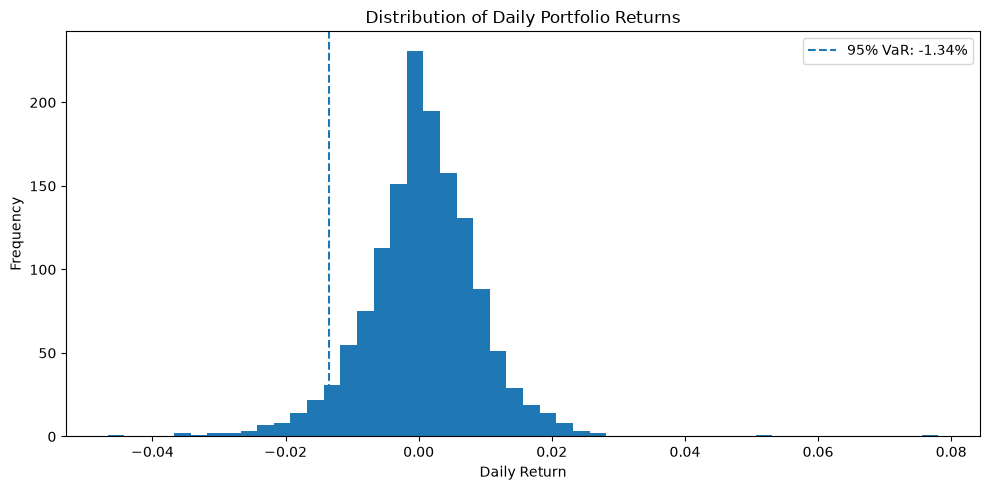

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_daily_returns,
    bins=50
)

plt.axvline(
    var_95,
    linestyle="--",
    label=f"95% VaR: {var_95:.2%}"
)

plt.title("Distribution of Daily Portfolio Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.savefig(
    "figures/return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 10. Expected Shortfall

Expected Shortfall measures the average portfolio return on days when losses exceed the VaR threshold.
Unlike VaR, it provides information about the severity of losses in the tail of the return distribution.

In [45]:
es_95 = portfolio_daily_returns[
    portfolio_daily_returns <= var_95
].mean()

es_99 = portfolio_daily_returns[
    portfolio_daily_returns <= var_99
].mean()

print(f"95% Expected Shortfall: {es_95:.2%}")
print(f"99% Expected Shortfall: {es_99:.2%}")

95% Expected Shortfall: -1.93%
99% Expected Shortfall: -2.90%


In [46]:
es_95_amount = portfolio_value * abs(es_95)
es_99_amount = portfolio_value * abs(es_99)

print(f"95% Expected Shortfall on £100,000: £{es_95_amount:,.2f}")
print(f"99% Expected Shortfall on £100,000: £{es_99_amount:,.2f}")

95% Expected Shortfall on £100,000: £1,934.41
99% Expected Shortfall on £100,000: £2,903.39


In [47]:
risk_summary = pd.Series({
    "Maximum Drawdown": max_drawdown,
    "95% VaR": var_95,
    "99% VaR": var_99,
    "95% Expected Shortfall": es_95,
    "99% Expected Shortfall": es_99
})

risk_summary.apply(lambda x: f"{x:.2%}")

Maximum Drawdown          -23.00%
95% VaR                    -1.34%
99% VaR                    -2.33%
95% Expected Shortfall     -1.93%
99% Expected Shortfall     -2.90%
dtype: str

### Risk Analysis

The portfolio's 95% one-day historical VaR is **1.34%**, increasing to **2.33%** at the 99% confidence level. The corresponding Expected Shortfalls are **1.93%** and **2.90%**, showing that losses beyond the VaR thresholds can be materially larger.
The portfolio's maximum historical peak-to-trough drawdown was **23.00%**.

## 11. Risk-Adjusted Performance

The Sharpe ratio measures portfolio return relative to the amount of volatility taken.
It compares the portfolio's return above the risk-free rate with its annualised volatility.

In [48]:
risk_free_rate = 0.04 #assumption

portfolio_sharpe = (
    (portfolio_return - risk_free_rate)
    / portfolio_volatility
)

print(f"Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")

Portfolio Sharpe Ratio: 0.78


In [49]:
asset_sharpe = (
    (annual_return - risk_free_rate)
    / annual_volatility
)

asset_sharpe

Ticker
GLD    0.692843
IEF   -0.737773
QQQ    0.627473
SPY    0.707994
XLF    0.632057
XLK    0.757004
dtype: float64

In [50]:
sharpe_comparison = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": asset_sharpe
})

sharpe_comparison

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
GLD,0.166263,0.182239,0.692843
IEF,-0.014928,0.074452,-0.737773
QQQ,0.181277,0.225153,0.627473
SPY,0.158465,0.167325,0.707994
XLF,0.156839,0.184856,0.632057
XLK,0.231072,0.252405,0.757004


In [51]:
sharpe_comparison.loc["Equal-Weight Portfolio"] = [
    portfolio_return,
    portfolio_volatility,
    portfolio_sharpe
]

sharpe_comparison

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
GLD,0.166263,0.182239,0.692843
IEF,-0.014928,0.074452,-0.737773
QQQ,0.181277,0.225153,0.627473
SPY,0.158465,0.167325,0.707994
XLF,0.156839,0.184856,0.632057
XLK,0.231072,0.252405,0.757004
Equal-Weight Portfolio,0.146498,0.137018,0.777254


### Observation

The equal-weight portfolio achieved a Sharpe ratio of **0.77**, slightly higher than any individual ETF in the sample. Although its annualised return of **14.60%** was lower than several equity ETFs, diversification reduced annualised volatility to **13.70%**.
This suggests that combining assets with different return relationships improved historical risk-adjusted performance rather than simply maximising return.

## 12. Market Exposure and Beta

Beta measures the sensitivity of an asset's returns to movements in the market. SPY is used as the market benchmark.
A beta above 1 indicates greater sensitivity to market movements, while a beta below 1 indicates lower market sensitivity.

In [52]:
market_returns = returns["SPY"]
market_variance = market_returns.var()

betas = {}

for ticker in returns.columns:
    covariance = returns[ticker].cov(market_returns)
    betas[ticker] = covariance / market_variance

betas = pd.Series(betas, name="Beta")

betas

GLD    0.169755
IEF    0.039417
QQQ    1.269412
SPY    1.000000
XLF    0.857116
XLK    1.375049
Name: Beta, dtype: float64

In [53]:
portfolio_beta = (
    portfolio_daily_returns.cov(market_returns)
    / market_variance
)

print(f"Portfolio Beta: {portfolio_beta:.2f}")

Portfolio Beta: 0.79


In [54]:
weighted_beta = np.dot(weights, betas.values)

print(f"Beta from portfolio returns: {portfolio_beta:.4f}")
print(f"Beta from weighted asset betas: {weighted_beta:.4f}")

Beta from portfolio returns: 0.7851
Beta from weighted asset betas: 0.7851


### Observation

QQQ and XLK showed the highest market sensitivity, with betas of **1.27** and **1.37**, respectively. GLD and IEF had much lower betas of **0.17** and **0.04**.
The equal-weight portfolio had a beta of **0.79**, indicating lower historical sensitivity to the equity market than SPY.

## 13. Final Results

The table below summarises the main performance and risk metrics for the equal-weight portfolio.

In [55]:
final_summary = pd.DataFrame({
    "Metric": [
        "Annualised Return",
        "Annualised Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "95% Historical VaR",
        "99% Historical VaR",
        "95% Expected Shortfall",
        "99% Expected Shortfall",
        "Market Beta"
    ],
    "Value": [
        f"{portfolio_return:.2%}",
        f"{portfolio_volatility:.2%}",
        f"{portfolio_sharpe:.2f}",
        f"{max_drawdown:.2%}",
        f"{var_95:.2%}",
        f"{var_99:.2%}",
        f"{es_95:.2%}",
        f"{es_99:.2%}",
        f"{portfolio_beta:.2f}"
    ]
})

final_summary

,Metric,Value
0,Annualised Return,14.65%
1,Annualised Volatility,13.70%
2,Sharpe Ratio,0.78
3,Maximum Drawdown,-23.00%
4,95% Historical VaR,-1.34%
5,99% Historical VaR,-2.33%
6,95% Expected Shortfall,-1.93%
7,99% Expected Shortfall,-2.90%
8,Market Beta,0.79


## Key Findings

The analysis shows that diversification depends on the relationships between assets rather than simply the number of holdings.

The equity ETFs were strongly correlated, particularly QQQ and XLK (0.97), meaning that combining them provides limited diversification. In contrast, GLD and IEF had much lower correlations with the equity ETFs.

The equal-weight portfolio generated an annualised return of approximately 14.60% with annualised volatility of 13.70%. Its Sharpe ratio of 0.77 was higher than that of any individual ETF in the sample, suggesting that diversification improved historical risk-adjusted performance.

The portfolio still experienced meaningful downside risk. Its maximum drawdown was 23.00%, while the 95% one-day historical VaR was 1.34% and the corresponding Expected Shortfall was 1.93%.

Finally, the portfolio beta of 0.79 indicates lower historical sensitivity to the equity market than SPY.

Overall, the results demonstrate how combining assets with different risk exposures can reduce portfolio volatility and market sensitivity without simply focusing on the highest-returning assets.

## Limitations

- The analysis is based on historical data and does not predict future returns or risk.
- The portfolio uses equal weights rather than an optimised allocation.
- Constant weights assume regular rebalancing.
- Historical VaR and Expected Shortfall depend on the observed sample period.
- A constant 4% annual risk-free rate is assumed for the Sharpe ratio.
- SPY is used as a proxy for the broader equity market when calculating beta.
- Transaction costs, taxes and trading constraints are not included.